In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# IterativeImputer ko enable karna required hai
from sklearn.experimental import enable_iterative_imputer

from sklearn.impute import (
    SimpleImputer,
    KNNImputer,
    IterativeImputer
)

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

print("Libraries imported successfully.")

Libraries imported successfully.


In [3]:
file_path = "salary_synthetic.csv"

df = pd.read_csv(file_path)

print("Dataset Shape:", df.shape)
print("Total Missing Values:", df.isna().sum().sum())
print("Duplicate Rows:", df.duplicated().sum())

df.head()

Dataset Shape: (2000, 15)
Total Missing Values: 1200
Duplicate Rows: 0


,age,gender,education,experience_years,role_seniority,company_size,location_tier,skills_count,certifications,worked_remote,last_promotion_years_ago,salary_bdt,recent_project_description_length,survey_date,recent_note
0,33,Male,M.Sc,6.0,Senior,Enterprise,Tier-2,1.0,2.0,1,0.0,145185,57.0,2024-11-15,Worked on microservices deployment
1,29,Male,M.Sc,9.0,Junior,Enterprise,Remote,5.0,0.0,1,0.0,121262,50.0,2024-03-08,Built ML pipeline for preprocessing
2,34,Male,B.Sc+Cert,NaN,Lead,Enterprise,Remote,5.0,1.0,1,5.0,184875,50.0,2024-09-01,Experience in data cleaning and ETL
3,39,Male,B.Sc,16.0,Mid,Enterprise,Tier-1,5.0,0.0,1,3.0,180105,59.0,2024-01-26,Contributed to open-source NLP repo
4,29,Female,B.Sc,8.0,Junior,SME,Tier-1,5.0,2.0,0,7.0,114750,NaN,2023-12-08,Built ML pipeline for preprocessing


In [4]:
missing_report = pd.DataFrame({
    "Missing_Count": df.isna().sum(),
    "Missing_Percentage": (
        df.isna().mean() * 100
    ).round(2)
})

missing_report = missing_report[
    missing_report["Missing_Count"] > 0
].sort_values(
    "Missing_Count",
    ascending=False
)

missing_report

,Missing_Count,Missing_Percentage
recent_note,300,15.0
recent_project_description_length,240,12.0
skills_count,200,10.0
experience_years,160,8.0
last_promotion_years_ago,120,6.0
education,100,5.0
certifications,80,4.0


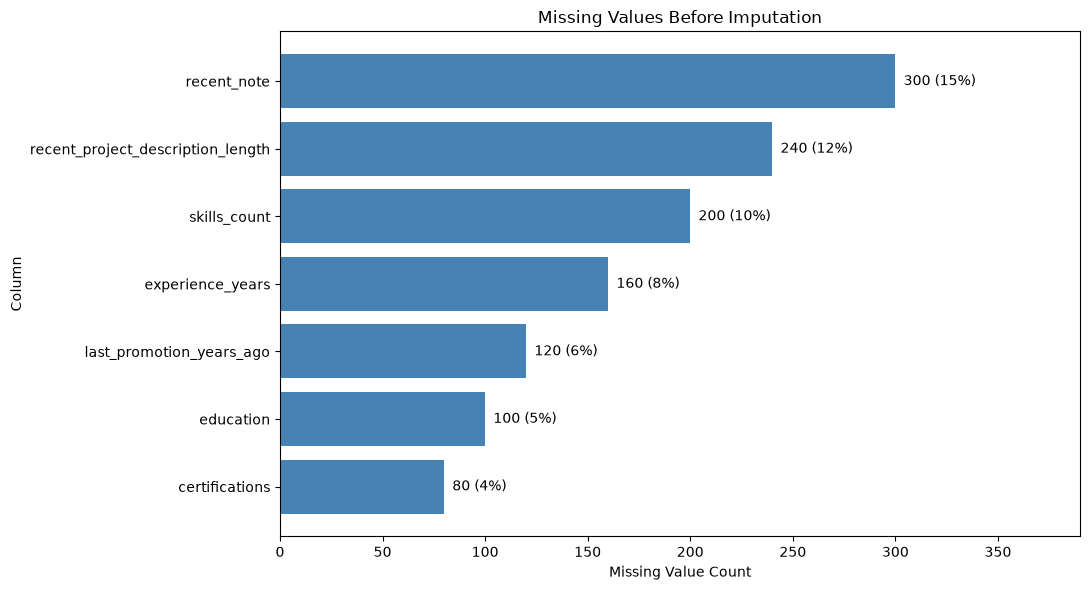

In [5]:
plt.figure(figsize=(11, 6))

bars = plt.barh(
    missing_report.index,
    missing_report["Missing_Count"],
    color="steelblue"
)

plt.gca().invert_yaxis()

plt.title("Missing Values Before Imputation")
plt.xlabel("Missing Value Count")
plt.ylabel("Column")

maximum = missing_report["Missing_Count"].max()
plt.xlim(0, maximum * 1.30)

for bar, count, percentage in zip(
    bars,
    missing_report["Missing_Count"],
    missing_report["Missing_Percentage"]
):
    plt.text(
        bar.get_width() + 4,
        bar.get_y() + bar.get_height() / 2,
        f"{count} ({percentage:.0f}%)",
        va="center"
    )

plt.tight_layout()
plt.show()

In [6]:
missing_columns = missing_report.index.tolist()

missing_patterns = (
    df[missing_columns]
    .isna()
    .apply(
        lambda row: " | ".join(
            column
            for column in missing_columns
            if row[column]
        ) or "Complete",
        axis=1
    )
    .value_counts()
)

pattern_report = (
    missing_patterns
    .rename_axis("Missing_Pattern")
    .reset_index(name="Rows")
)

pattern_report["Percentage"] = (
    pattern_report["Rows"] / len(df) * 100
).round(2)

pattern_report.head(10)

,Missing_Pattern,Rows,Percentage
0,Complete,1065,53.25
1,recent_note,192,9.60
2,recent_project_description_length,153,7.65
3,skills_count,117,5.85
4,experience_years,82,4.10
5,last_promotion_years_ago,74,3.70
6,education,45,2.25
7,certifications,45,2.25
8,recent_note | experience_years,21,1.05
9,recent_note | recent_project_description_length,20,1.00


In [7]:
df["survey_date"] = pd.to_datetime(
    df["survey_date"],
    format="%Y-%m-%d",
    errors="coerce"
)

df["survey_year"] = df["survey_date"].dt.year
df["survey_month"] = df["survey_date"].dt.month
df["survey_day"] = df["survey_date"].dt.day

print("Date features created successfully.")

Date features created successfully.


In [8]:
numerical_features = [
    "age",
    "experience_years",
    "skills_count",
    "certifications",
    "worked_remote",
    "last_promotion_years_ago",
    "recent_project_description_length",
    "survey_year",
    "survey_month",
    "survey_day"
]

categorical_features = [
    "gender",
    "education",
    "role_seniority",
    "company_size",
    "location_tier",
    "recent_note"
]

target_column = "salary_bdt"

print("Numerical Features:", numerical_features)
print("\nCategorical Features:", categorical_features)
print("\nTarget:", target_column)

Numerical Features: ['age', 'experience_years', 'skills_count', 'certifications', 'worked_remote', 'last_promotion_years_ago', 'recent_project_description_length', 'survey_year', 'survey_month', 'survey_day']

Categorical Features: ['gender', 'education', 'role_seniority', 'company_size', 'location_tier', 'recent_note']

Target: salary_bdt


In [9]:
X = df[
    numerical_features + categorical_features
]

y = df[target_column]

print("X Shape:", X.shape)
print("y Shape:", y.shape)

X Shape: (2000, 16)
y Shape: (2000,)


In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Rows:", X_train.shape[0])
print("Testing Rows:", X_test.shape[0])

Training Rows: 1600
Testing Rows: 400


In [11]:
imputation_methods = {
    "Median (Baseline)": SimpleImputer(
        strategy="median"
    ),
    
    "KNN": KNNImputer(
        n_neighbors=5,
        weights="distance"
    ),
    
    "Iterative": IterativeImputer(
        max_iter=20,
        initial_strategy="median",
        random_state=42
    )
}

print("Imputation methods created successfully.")

Imputation methods created successfully.


In [12]:
results = []
trained_pipelines = {}

for method_name, numerical_imputer in imputation_methods.items():
    
    numerical_pipeline = Pipeline(
        steps=[
            (
                "scaler",
                StandardScaler()
            ),
            (
                "imputer",
                numerical_imputer
            )
        ]
    )
    
    categorical_pipeline = Pipeline(
        steps=[
            (
                "imputer",
                SimpleImputer(
                    strategy="most_frequent"
                )
            ),
            (
                "encoder",
                OneHotEncoder(
                    handle_unknown="ignore"
                )
            )
        ]
    )
    
    preprocessor = ColumnTransformer(
        transformers=[
            (
                "numerical",
                numerical_pipeline,
                numerical_features
            ),
            (
                "categorical",
                categorical_pipeline,
                categorical_features
            )
        ]
    )
    
    model_pipeline = Pipeline(
        steps=[
            (
                "preprocessor",
                preprocessor
            ),
            (
                "model",
                RandomForestRegressor(
                    n_estimators=300,
                    min_samples_leaf=2,
                    random_state=42,
                    n_jobs=-1
                )
            )
        ]
    )
    
    model_pipeline.fit(
        X_train,
        y_train
    )
    
    predictions = model_pipeline.predict(
        X_test
    )
    
    mae = mean_absolute_error(
        y_test,
        predictions
    )
    
    rmse = np.sqrt(
        mean_squared_error(
            y_test,
            predictions
        )
    )
    
    r2 = r2_score(
        y_test,
        predictions
    )
    
    results.append({
        "Method": method_name,
        "MAE": mae,
        "RMSE": rmse,
        "R2_Score": r2
    })
    
    trained_pipelines[method_name] = model_pipeline

print("All imputation methods evaluated successfully.")

All imputation methods evaluated successfully.


In [13]:
# Convert model results into a DataFrame
results_df = pd.DataFrame(results)

# Sort methods: highest R² and lowest RMSE first
results_df = results_df.sort_values(
    by=["R2_Score", "RMSE"],
    ascending=[False, True]
).reset_index(drop=True)

# Round numerical results
results_df[
    ["MAE", "RMSE", "R2_Score"]
] = results_df[
    ["MAE", "RMSE", "R2_Score"]
].round(4)

print("Imputation Method Comparison:")
display(results_df)

Imputation Method Comparison:


,Method,MAE,RMSE,R2_Score
0,Iterative,13816.0794,30147.0386,0.7117
1,Median (Baseline),14200.2411,30253.0678,0.7097
2,KNN,14205.8493,30623.3876,0.7025


In [14]:
best_method = results_df.iloc[0]["Method"]

print("Best Imputation Method:", best_method)

Best Imputation Method: Iterative


In [15]:
numerical_data = df[numerical_features]

scaler = StandardScaler()

scaled_numerical_data = scaler.fit_transform(
    numerical_data
)

final_numerical_imputer = IterativeImputer(
    max_iter=20,
    initial_strategy="median",
    random_state=42
)

imputed_scaled_data = (
    final_numerical_imputer.fit_transform(
        scaled_numerical_data
    )
)

imputed_numerical_data = (
    scaler.inverse_transform(
        imputed_scaled_data
    )
)

df_imputed = df.copy()

df_imputed[numerical_features] = (
    imputed_numerical_data
)

print("Numerical missing values imputed.")

Numerical missing values imputed.


In [16]:
categorical_imputer = SimpleImputer(
    strategy="most_frequent"
)

df_imputed[categorical_features] = (
    categorical_imputer.fit_transform(
        df_imputed[categorical_features]
    )
)

print("Categorical missing values imputed.")

Categorical missing values imputed.


In [17]:
integer_columns = [
    "age",
    "skills_count",
    "certifications",
    "worked_remote",
    "last_promotion_years_ago",
    "recent_project_description_length",
    "survey_year",
    "survey_month",
    "survey_day"
]

for column in integer_columns:
    df_imputed[column] = (
        df_imputed[column]
        .round()
        .astype("int64")
    )

df_imputed["experience_years"] = (
    df_imputed["experience_years"]
    .round(2)
)

print("Count-like columns corrected.")

Count-like columns corrected.


In [18]:
df_imputed.insert(
    0,
    "data_version",
    "v2.0"
)

df_imputed["imputation_method"] = (
    "Iterative"
)

df_imputed["survey_date"] = (
    df_imputed["survey_date"]
    .dt.strftime("%Y-%m-%d")
)

print("Final dataset version: v2.0")

Final dataset version: v2.0


In [19]:
print("Final Dataset Shape:", df_imputed.shape)

print(
    "Missing Values Before:",
    df.isna().sum().sum()
)

print(
    "Missing Values After:",
    df_imputed.isna().sum().sum()
)

print(
    "Missing Values in Target:",
    df_imputed["salary_bdt"].isna().sum()
)

print(
    "Duplicate Rows:",
    df_imputed.duplicated().sum()
)

Final Dataset Shape: (2000, 20)
Missing Values Before: 1200
Missing Values After: 0
Missing Values in Target: 0
Duplicate Rows: 0


In [21]:
df_imputed.to_csv(
    "salary_imputed_v2_0.csv",
    index=False
)

results_df.to_csv(
    "imputation_model_comparison.csv",
    index=False
)

missing_report.to_csv(
    "missing_value_report.csv"
)

pattern_report.to_csv(
    "missing_pattern_report.csv",
    index=False
)

print("All Task  files saved successfully.")

All Task  files saved successfully.
